# FastRP Python Demo

This notebook demonstrates how to use the high-performance Python bindings of the `fastrp` library.

In [1]:
# !pip install numpy scipy networkx matplotlib scikit-learn

In [2]:
import numpy as np
import networkx as nx
import scipy.sparse as sp
import fastrp

print("fastrp successfully imported!")

fastrp successfully imported!


In [3]:
# Load Zachary's Karate Club graph, a standard social network benchmark
G = nx.karate_club_graph()
n_nodes = G.number_of_nodes()
print(f"Graph loaded with {n_nodes} nodes and {G.number_of_edges()} edges.")

Graph loaded with 34 nodes and 78 edges.


In [4]:
nx.adjacency_matrix(G).toarray()

array([[0, 4, 5, ..., 2, 0, 0],
       [4, 0, 6, ..., 0, 0, 0],
       [5, 6, 0, ..., 0, 2, 0],
       ...,
       [2, 0, 0, ..., 0, 4, 4],
       [0, 0, 2, ..., 4, 0, 5],
       [0, 0, 0, ..., 4, 5, 0]], shape=(34, 34))

In [5]:
# 1. Adjacency List format: list of list of (neighbor_id, weight)
adj_list = [ [(neighbor, data.get('weight', 1.0)) for neighbor, data in G[node].items()]
    for node in G.nodes()
           ]

# Instantiate FastRP and fit
model = fastrp.FastRP(dim=16, weights=[0.0, 1.0, 1.0], seed=42, undirected=True)
embeddings_adj = model.fit_transform(adj_list)
print("Embeddings shape (adjacency list):", embeddings_adj.shape)

Embeddings shape (adjacency list): (34, 16)


In [6]:
# 2. Dense Adjacency Matrix format
adj_matrix = nx.to_numpy_array(G)

model_dense = fastrp.FastRP(dim=16, weights=[0.0, 1.0, 1.0], seed=42, undirected=True)
embeddings_dense = model_dense.fit_transform(adj_matrix)
print("Embeddings shape (dense):", embeddings_dense.shape)

# Verify outputs match
assert np.allclose(embeddings_adj, embeddings_dense, atol=1e-5)
print("Success: Adjacency list and Dense embeddings are identical!")

Embeddings shape (dense): (34, 16)
Success: Adjacency list and Dense embeddings are identical!


In [7]:
# 3. Scipy CSR Sparse Matrix format
adj_sparse = nx.to_scipy_sparse_array(G, format="csr")

model_csr = fastrp.FastRP(dim=16, weights=[0.0, 1.0, 1.0], seed=42, undirected=True)
embeddings_csr = model_csr.fit_transform(adj_sparse)
print("Embeddings shape (CSR sparse):", embeddings_csr.shape)

# Verify outputs match
assert np.allclose(embeddings_adj, embeddings_csr, atol=1e-5)
print("Success: CSR embeddings match others!")

Embeddings shape (CSR sparse): (34, 16)
Success: CSR embeddings match others!


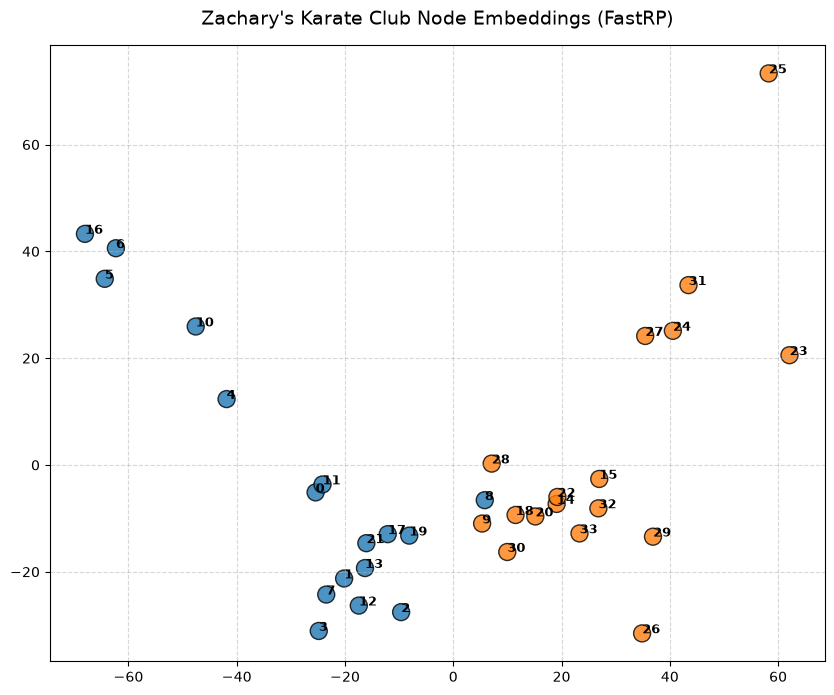

In [8]:
# Visualize the generated node embeddings in 2D using PCA
try:
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA
    
    pca = PCA(n_components=2)
    emb_2d = pca.fit_transform(embeddings_dense)
    
    # Node colors based on club faction
    colors = ["#1f77b4" if G.nodes[node]["club"] == "Mr. Hi" else "#ff7f0e" for node in G.nodes()]
    
    plt.figure(figsize=(10, 8))
    plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=colors, s=150, edgecolors="black", alpha=0.8)
    
    # Add labels
    for node in G.nodes():
        plt.text(emb_2d[node, 0] + 0.02, emb_2d[node, 1] + 0.02, str(node), fontsize=9, weight="bold")
        
    plt.title("Zachary's Karate Club Node Embeddings (FastRP)", fontsize=14, pad=15)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
except ImportError:
    print("Please install scikit-learn and matplotlib to view the visual embeddings plot.")